# DMD Smoke Tests

Staged tests for DMD configuration, pattern generation, display, calibration, and cleanup. Virtual hardware is the safe default. Physical/window output remains disabled until `RUN_DMD_DISPLAY` is deliberately enabled.

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import sys
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)


def find_repo_root() -> Path:
    """Return the repository root containing the evomachine package."""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "evomachine" / "peripherals" / "dmd.py").is_file():
            return candidate
    raise RuntimeError("Could not find the EvoMachine repository root.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from evomachine.bindings.binding_types import BindingType
from evomachine.bindings.em_dmd_window.peripheralcontroller import EmDmdWindowPeripheralController
from evomachine.bindings.pygame.peripheralcontroller import PygameDmdPeripheralController
from evomachine.bindings.virtual.dmd import VirtualDmdPeripheralController
from evomachine.peripherals.dmd import DmdConfig, DmdFactory


@dataclass(frozen=True, kw_only=True)
class DmdTestSettings:
    binding: BindingType = BindingType.VIRTUAL
    dmd_size: tuple[int, int] = (2716, 1600)
    camera_size: tuple[int, int] = (3200, 3200)
    display_offset: tuple[int, int] = (0, 0)
    monitor_index: int | None = None
    calibration_file: Path = REPO_ROOT / "evomachine" / "dmd_calibration_data.pkl"
    pattern_duration_s: float = 2.0
    checker_square_size: int = 100
    line_width: int = 5


VIRTUAL_SETTINGS = DmdTestSettings()
# Set monitor_index to the dedicated DMD display before using pygame.
# None means the primary desktop and is deliberately blocked below.
PYGAME_SETTINGS = DmdTestSettings(binding=BindingType.PYGAME, monitor_index=None)
EM_WINDOW_SETTINGS = DmdTestSettings(binding=BindingType.EM_DMD_WINDOW)

SETTINGS = EM_WINDOW_SETTINGS  # Select VIRTUAL_SETTINGS, PYGAME_SETTINGS, or EM_WINDOW_SETTINGS.
RUN_DMD_DISPLAY = True  # Required for real window/process output.
ALLOW_FULLSCREEN_PYGAME = False  # Second guard: pygame has no Escape-key handler.
SETTINGS

/home/hslab/workspace_python/evomachine_refactor/evomachine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DmdTestSettings(binding=<BindingType.EM_DMD_WINDOW: 5>, dmd_size=(2716, 1600), camera_size=(3200, 3200), display_offset=(0, 0), monitor_index=None, calibration_file=PosixPath('/home/hslab/workspace_python/evomachine_refactor/evomachine/evomachine/dmd_calibration_data.pkl'), pattern_duration_s=2.0, checker_square_size=100, line_width=5)

## Preflight checks

This verifies local dependencies without opening a display.

In [2]:
em_window_program = REPO_ROOT.parent / "em_dmd_window" / "Release" / "evomachine_dmd_window"
{
    "binding": SETTINGS.binding,
    "dmd_size": SETTINGS.dmd_size,
    "camera_size": SETTINGS.camera_size,
    "calibration_file": SETTINGS.calibration_file,
    "calibration_exists": SETTINGS.calibration_file.is_file(),
    "em_window_program": em_window_program,
    "em_window_program_exists": em_window_program.is_file(),
    "display_enabled": RUN_DMD_DISPLAY,
}

{'binding': <BindingType.EM_DMD_WINDOW: 5>,
 'dmd_size': (2716, 1600),
 'camera_size': (3200, 3200),
 'calibration_file': PosixPath('/home/hslab/workspace_python/evomachine_refactor/evomachine/evomachine/dmd_calibration_data.pkl'),
 'calibration_exists': True,
 'em_window_program': PosixPath('/home/hslab/workspace_python/evomachine_refactor/em_dmd_window/Release/evomachine_dmd_window'),
 'em_window_program_exists': True,
 'display_enabled': True}

## Create and initialise the DMD

When physical output is disabled, pygame and `em_dmd_window` use debug mode: no fullscreen window, process, socket connection, or image transmission occurs. Pygame is refused when `monitor_index` is `None`, because that would cover the primary desktop with a borderless black surface.

In [3]:
previous_dmd = globals().get("dmd")
if previous_dmd is not None and previous_dmd.is_initialised():
    previous_dmd.stop()
    previous_dmd.finalise()

if SETTINGS.binding == BindingType.PYGAME and RUN_DMD_DISPLAY:
    if SETTINGS.monitor_index is None:
        raise RuntimeError(
            "Refusing fullscreen pygame on the primary display. Set monitor_index to the dedicated DMD display."
        )
    if not ALLOW_FULLSCREEN_PYGAME:
        raise RuntimeError(
            "Set ALLOW_FULLSCREEN_PYGAME = True only after confirming monitor_index identifies the DMD display."
        )

if SETTINGS.binding == BindingType.VIRTUAL:
    dmd_controller = VirtualDmdPeripheralController()
elif SETTINGS.binding == BindingType.PYGAME:
    dmd_controller = PygameDmdPeripheralController(debug_mode=not RUN_DMD_DISPLAY)
elif SETTINGS.binding == BindingType.EM_DMD_WINDOW:
    dmd_controller = EmDmdWindowPeripheralController(debug_mode=not RUN_DMD_DISPLAY)
else:
    raise ValueError(f"Unsupported DMD binding: {SETTINGS.binding}")

dmd_config = DmdConfig(
    binding=SETTINGS.binding,
    width_height_DMD=SETTINGS.dmd_size,
    width_height_CAM=SETTINGS.camera_size,
    display_offset=SETTINGS.display_offset,
    monitor_index=SETTINGS.monitor_index,
    calibration_file=SETTINGS.calibration_file,
)
dmd = DmdFactory.create(dmd_config, peripheral_controllers=dmd_controller)
dmd.initialise()

{
    "name": dmd.name,
    "binding": dmd.config.binding,
    "initialised": dmd.is_initialised(),
    "alive": dmd.is_alive(),
    "calibrated": dmd.is_calibrated(),
    "calibration_file": dmd.get_calibration_filename(),
    "dmd_size": dmd.width_height_DMD,
}

2026-07-02 14:09:49 - INFO - evomachine.peripherals.dmd - Dmd.load_calibration_data: loading calibration data from /home/hslab/workspace_python/evomachine_refactor/evomachine/evomachine/dmd_calibration_data.pkl.
2026-07-02 14:09:49 - DEBUG - evomachine.peripherals.dmd - Dmd.initialise: initialising em_dmd_window DMD with force=False.
INFO:evomachine.bindings.em_dmd_window.peripheralcontroller:EmDmdWindowPeripheralController.initialise: initialising DMD socket backend.


{'name': 'em_dmd_window DMD',
 'binding': <BindingType.EM_DMD_WINDOW: 5>,
 'initialised': True,
 'alive': True,
 'calibrated': True,
 'calibration_file': PosixPath('/home/hslab/workspace_python/evomachine_refactor/evomachine/evomachine/dmd_calibration_data.pkl'),
 'dmd_size': (2716, 1600)}

## Generate and inspect patterns locally

Pattern creation does not send anything to the DMD. The preview is downsampled for responsive notebook rendering.

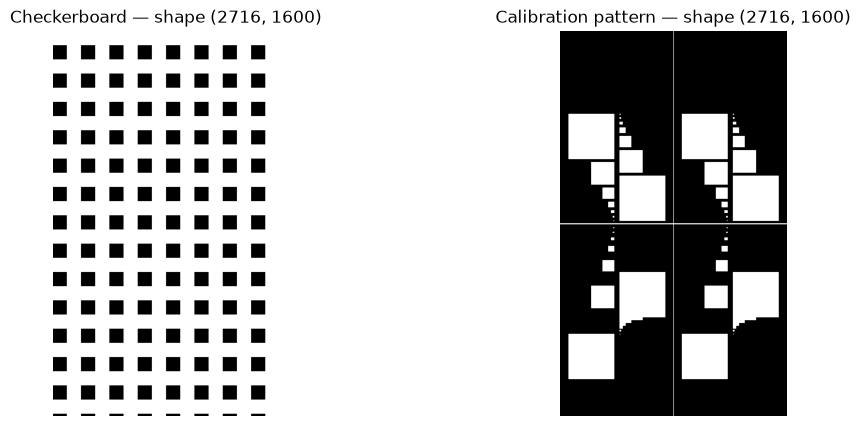

{'checkerboard_dtype': dtype('uint8'),
 'checkerboard_values': array([  0, 255], dtype=uint8),
 'crosshair_dtype': dtype('uint8')}

In [4]:
checkerboard = dmd.get_checkerboard(square_size=SETTINGS.checker_square_size)
crosshair = dmd.get_calibration_image(lw=SETTINGS.line_width)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, pattern, title in zip(
    axes,
    (checkerboard, crosshair),
    ("Checkerboard", "Calibration pattern"),
):
    axis.imshow(pattern[::4, ::4], cmap="gray", vmin=0, vmax=255)
    axis.set_title(f"{title} — shape {pattern.shape}")
    axis.set_axis_off()
plt.show()

{
    "checkerboard_dtype": checkerboard.dtype,
    "checkerboard_values": np.unique(checkerboard),
    "crosshair_dtype": crosshair.dtype,
}

## Display one timed pattern

The DMD is blanked in `finally`, including when transmission fails. For virtual mode this exercises the identical API in memory. A pygame test also closes its fullscreen surface automatically, so rerun the creation cell before another display test.

In [6]:
if SETTINGS.binding != BindingType.VIRTUAL and not RUN_DMD_DISPLAY:
    raise RuntimeError("Set RUN_DMD_DISPLAY = True and rerun the creation cell before physical display.")

try:
    dmd.display_image(checkerboard)
    time.sleep(SETTINGS.pattern_duration_s)
finally:
    dmd.display_none()
    if SETTINGS.binding == BindingType.PYGAME:
        dmd.finalise()

{
    "is_full_display": dmd.is_full_display(),
    "display_blank_after_test": True,
    "initialised_after_test": dmd.is_initialised(),
}

2026-07-02 14:10:10 - DEBUG - evomachine.peripherals.dmd - Dmd.display_none: displaying black screen on em_dmd_window DMD.


{'is_full_display': False,
 'display_blank_after_test': True,
 'initialised_after_test': True}

## Check calibration geometry

This transforms the camera centre to DMD coordinates without displaying it.

In [14]:
if not dmd.is_calibrated():
    raise RuntimeError(f"No usable calibration was loaded from {dmd.get_calibration_filename()}.")

camera_centre = (SETTINGS.camera_size[0] // 2, SETTINGS.camera_size[1] // 2)
dmd_centre = dmd.img_to_dmd_coords(*camera_centre)
{"camera_coordinate": camera_centre, "dmd_coordinate": dmd_centre}

{'camera_coordinate': (1600, 1600), 'dmd_coordinate': (1357, 788)}

## Cleanup

Always blank the DMD and release its display/socket controller before switching bindings.

In [8]:
if "dmd" in globals() and dmd is not None and dmd.is_initialised():
    dmd.stop()
    dmd.finalise()

{"dmd_initialised": dmd.is_initialised(), "controller_initialised": dmd_controller.is_initialised()}

{'dmd_initialised': False, 'controller_initialised': False}